<a href="https://colab.research.google.com/github/Sza288/ProyekMakalah_ASA/blob/main/downtown_singapore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Analisis Algoritma: Penentuan Rute Belanja Singapura

**Referensi Materi (GeeksforGeeks):**
1. [Greedy Algorithm](https://www.geeksforgeeks.org/greedy-algorithms/)
2. [Uniform Cost Search](https://www.geeksforgeeks.org/uniform-cost-search-dijkstra-for-unweighted-graphs/)
3. [A* Search Algorithm](https://www.geeksforgeeks.org/a-search-algorithm/)
4. [TSP Dynamic Programming](https://www.geeksforgeeks.org/travelling-salesman-problem-using-dynamic-programming/)
5. [MST for Heuristic](https://www.geeksforgeeks.org/prims-minimum-spanning-tree-mst-greedy-algo-5/)

In [1]:
# 1. Install & Import
!pip install osmnx networkx pandas tabulate -q

import osmnx as ox
import networkx as nx
import numpy as np
import folium
from IPython.display import display, Markdown
import pandas as pd
import time, heapq
from tabulate import tabulate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.6 MB/s eta 0:00:00


In [ ]:
# 2a. Data Lokasi & Matriks
LOKASI = {
    "Bugis Junction": (1.2993, 103.8554),
    "The Shoppes MBS": (1.2845, 103.8590),
    "Raffles City": (1.2940, 103.8531),
    "Bugis Street": (1.3006, 103.8549),
    "Esplanade Mall": (1.2897, 103.8562),
    "Suntec City": (1.2955, 103.8585),
    "Chijmes": (1.2949, 103.8526),
    "Merlion Park": (1.2870, 103.8545),
    "Marina Square": (1.2922, 103.8586),
    "Funan": (1.2915, 103.8499),
    "National Gallery": (1.2909, 103.8517),
    "Fort Canning": (1.2953, 103.8468),
    "Singapore Flyer": (1.2901, 103.8627),
    "Clarke Quay": (1.2903, 103.8467),
    "Old Hill Street": (1.2909, 103.8481)
}

print("Downloading graph and mapping nodes...")
G = ox.graph_from_place("Downtown Core, Singapore", network_type="walk")
# Preprocessing: Mapping GPS ke Node terdekat di graf
nodes = [ox.nearest_nodes(G, lon, lat) for lat, lon in LOKASI.values()]
names = list(LOKASI.keys())
n = len(names)

# Membangun Matriks Jarak 15x15
dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            try: dist_matrix[i][j] = nx.shortest_path_length(G, nodes[i], nodes[j], weight='length')
            except: dist_matrix[i][j] = 9999

print("Matriks Jarak 15x15 :")
print("[\n" + "\n".join(["  [" + ", ".join([f"{v:7.1f}" for v in row]) + "]" for row in dist_matrix]) + "\n]")

Matriks Jarak 15x15 [Format LaTeX]:
[
  [    0.0,  2298.7,  1041.0,   344.3,  1499.8,   819.5,   628.6,  1640.4,  1463.5,  1258.8,  1139.3,   928.6,  1694.8,  1375.9,  1359.9]
  [ 2298.7,     0.0,  1720.7,  2335.8,  1183.4,  1536.0,  1984.9,  1588.1,  1339.6,  2295.9,  1885.3,  2060.0,   973.5,  2277.0,  2292.1]
  [ 1041.0,  1720.7,     0.0,  1365.2,   785.4,   922.5,   557.8,   926.0,  1064.2,   914.4,   538.3,   616.6,  1379.5,  1016.7,  1015.5]
  [  344.3,  2335.8,  1365.2,     0.0,  1814.3,   936.4,   952.8,  1954.9,  1599.4,  1473.6,  1463.6,  1143.4,  1731.9,  1590.7,  1574.7]
  [ 1499.8,  1183.4,   785.4,  1814.3,     0.0,   957.1,  1051.8,   430.8,   742.0,  1216.3,   805.8,  1105.2,   842.2,  1119.7,  1134.8]
  [  819.5,  1536.0,   922.5,   936.4,   957.1,     0.0,   964.6,  1246.4,   727.7,  1623.9,  1227.9,  1330.5,   932.1,  1726.2,  1725.0]
  [  628.6,  1984.9,   557.8,   952.8,  1051.8,   964.6,     0.0,  1192.4,  1076.7,   839.4,   642.8,   516.8,  1511.1,   956.6,   940

Graf jaringan pejalan kaki Downtown Core, Singapore : 
   Jumlah node : 2591
   Jumlah edge : 7422


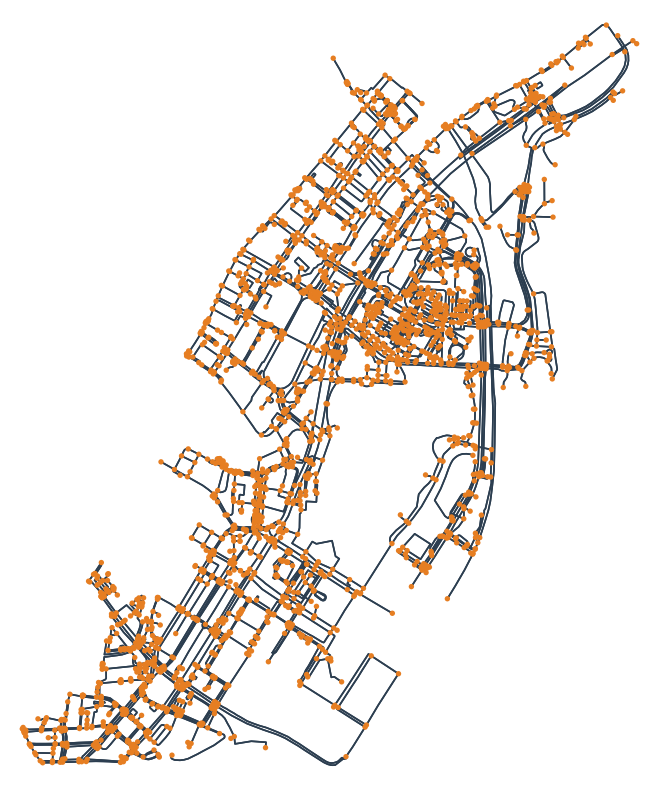

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

In [ ]:
# 2b. Visualisasi Graf Jaringan Pejalan Kaki
print(f"Graf jaringan pejalan kaki Downtown Core, Singapore : ")
print(f"   Jumlah node : {len(G.nodes)}")
print(f"   Jumlah edge : {len(G.edges)}")

# Menggunakan node_color merah dan edge_color biru sesuai permintaan
ox.plot_graph(
    G,
    node_size=15,
    node_color='#e74c3c',
    edge_color='#2980b9',
    edge_linewidth=1.2,
    bgcolor='white',
    figsize=(10, 10)
)

In [ ]:
# 2c. Visualisasi Graf Lengkap (Interaktif dengan Folium)
pusat = [1.291, 103.855]
m = folium.Map(location=pusat, zoom_start=14)

# Tambahkan Marker untuk setiap lokasi
for name, coord in LOKASI.items():
    if name == "Bugis Junction":
        # Titik awal dengan icon berbeda
        folium.Marker(location=coord, popup=f"START: {name}", icon=folium.Icon(color='red', icon='star')).add_to(m)
    else:
        folium.Marker(location=coord, popup=name, icon=folium.Icon(color='blue', icon='shopping-cart')).add_to(m)

# Visualisasi koneksi (Edge) antar 15 lokasi
for i in range(n):
    for j in range(i + 1, n):
        folium.PolyLine([LOKASI[names[i]], LOKASI[names[j]]], color='blue', weight=1, opacity=0.3).add_to(m)

display(Markdown("### Representasi Graf Lengkap 15 Lokasi Belanja"))
display(m)

### Representasi Graf Lengkap 15 Lokasi Belanja

Graf jaringan pejalan kaki Downtown Core, Singapore : 
   Jumlah node : 2,591
   Jumlah edge : 7,422


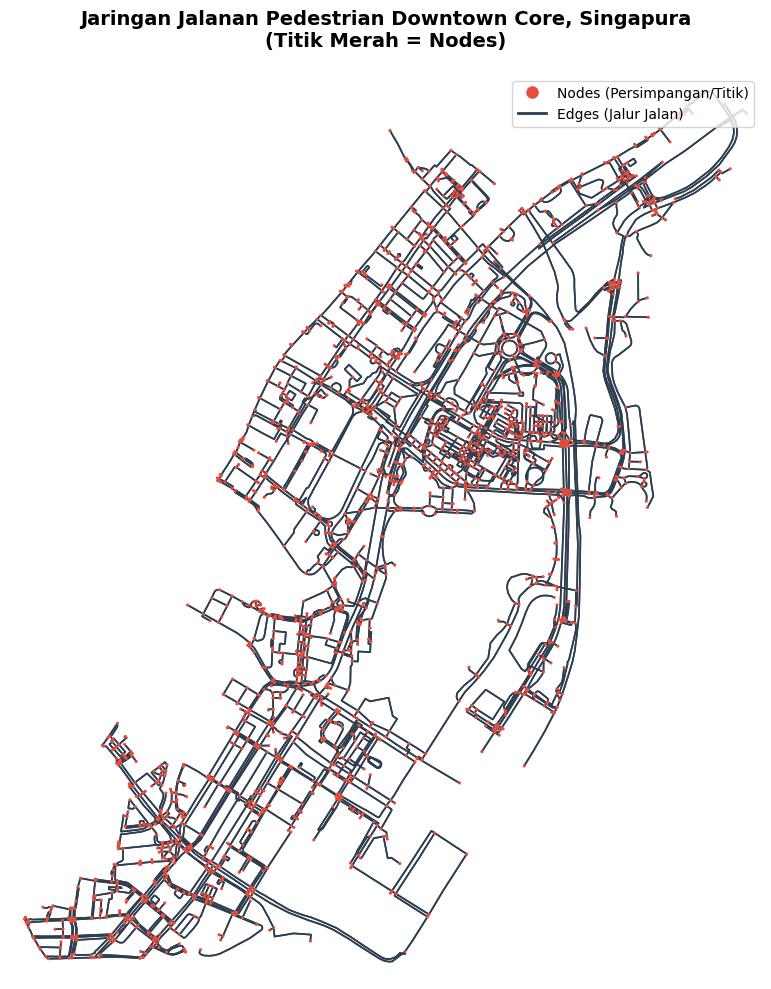

In [ ]:
# 3. Algoritma 1: Greedy (Nearest Neighbor)
def run_greedy(mat):
    n = len(mat)
    path = [0]; visited = {0}; total = 0
    for _ in range(n-1):
        curr = path[-1]
        nxt = min([(mat[curr][i], i) for i in range(n) if i not in visited])[1]
        total += mat[curr][nxt]
        path.append(nxt)
        visited.add(nxt)
    return total + mat[path[-1]][0]

In [ ]:
# ------------------------------------------------------------------------------
# Fungsi Pembantu
# ------------------------------------------------------------------------------

def hitung_total_jarak(rute, mat):
    """
    Menghitung total bobot dari sebuah rute berdasarkan matriks yang diberikan.
    """
    total = 0.0
    for k in range(len(rute) - 1):
        total += mat[rute[k]][rute[k + 1]]
    return total

def format_rute(rute, daftar_nama):
    """
    Mengonversi list indeks rute menjadi string nama lokasi.
    """
    return " → ".join(daftar_nama[i] for i in rute)

def list_target(n, start_idx=0):
    """
    Mengembalikan list indeks lokasi yang harus dikunjungi selain titik awal.
    """
    return [i for i in range(n) if i != start_idx]

# --- FUNGSI UTILITAS: Minimum Spanning Tree (Prim's Algorithm) ---

def hitung_mst_prim(simpul_tersisa, matriks_jarak):
    """
    Menghitung bobot MST dari sekumpulan simpul yang tersisa.
    Digunakan sebagai fungsi heuristik yang admissible.
    """
    if len(simpul_tersisa) <= 1:
        return 0.0

    nodes = list(simpul_tersisa)
    dikunjungi = {nodes[0]}

    # Priority Queue untuk menyimpan edge (bobot, simpul_tujuan)
    pq_mst = []
    for v in nodes[1:]:
        heapq.heappush(pq_mst, (matriks_jarak[nodes[0]][v], v))

    total_mst = 0.0
    while pq_mst and len(dikunjungi) < len(nodes):
        bobot, u = heapq.heappop(pq_mst)

        if u in dikunjungi:
            continue

        dikunjungi.add(u)
        total_mst += bobot

        for v in nodes:
            if v not in dikunjungi:
                heapq.heappush(pq_mst, (matriks_jarak[u][v], v))

    return total_mst

# --- CONTOH PENGGUNAAN ---
if 'dist_matrix' in globals() and 'names' in globals():
    # Contoh rute sederhana: 0 -> 1 -> 2 -> 0
    sample_route = [0, 1, 2, 0]

    print("--- Demonstrasi Fungsi Pembantu ---")
    print(f"Rute Terformat: {format_rute(sample_route, names)}")
    print(f"Total Jarak   : {hitung_total_jarak(sample_route, dist_matrix):.2f} m")

    targets = list_target(len(names))
    mst_val = hitung_mst_prim(targets, dist_matrix)
    print(f"Bobot MST (Heuristik) untuk simpul tersisa: {mst_val:.2f} m")

In [ ]:
def create_adj_list(mat):
    """Mengonversi matriks jarak ke adjacency list untuk algoritma."""
    n = len(mat)
    adj = [[] for _ in range(n)]
    for u in range(n):
        for v in range(n):
            if u != v:
                adj[u].append([v, mat[u][v]])
    return adj

def run_approx_tsp_mst(mat):
    """
    Implementasi Greedy TSP menggunakan MST sebagai fungsi heuristik.
    """
    n = len(mat)
    adj = create_adj_list(mat)

    # 1. Cari MST
    mst_cost_container = [0]
    mst_edges = findMST(adj, mst_cost_container)

    # 2. Bangun Adjacency List untuk MST
    mst_adj = [[] for _ in range(n)]
    for e in mst_edges:
        mst_adj[e[0]].append([e[1], e[2]])
        mst_adj[e[1]].append([e[0], e[2]])

    # 3. Eulerian Circuit (Pre-order traversal pada MST)
    tour = []
    visited = [False] * n
    eulerianCircuit(mst_adj, 0, tour, visited, -1)
    tour.append(0) # Kembali ke awal

    # 4. Hitung Total Jarak menggunakan fungsi pembantu
    total_jarak = hitung_total_jarak(tour, mat)
    return tour, total_jarak

In [ ]:
# Update Tabel Perbandingan dengan Algoritma Baru
results_v2 = []
limit_n = 10

# 1. Greedy (Nearest Neighbor)
t0 = time.time(); d1 = run_greedy(dist_matrix); t1 = (time.time()-t0)*1000
results_v2.append(["Greedy (NN)", f"{d1:.1f} m", f"{t1:.2f} ms"])

# 2. Greedy (MST-based Approx)
t0 = time.time(); r_mst, d_mst = run_approx_tsp_mst(dist_matrix[:limit_n, :limit_n]); t_mst = (time.time()-t0)*1000
results_v2.append(["Greedy (MST Approx)", f"{d_mst:.1f} m", f"{t_mst:.2f} ms"])

# 3. A* (MST Heuristic)
t0 = time.time(); d3 = run_astar(dist_matrix, limit_n); t3 = (time.time()-t0)*1000
results_v2.append(["A* (MST Heuristic)", f"{d3:.1f} m", f"{t3:.2f} ms"])

# 4. Dynamic Programming
t0 = time.time(); d4 = run_dp(dist_matrix, limit_n); t4 = (time.time()-t0)*1000
results_v2.append(["DP (Held-Karp)", f"{d4:.1f} m", f"{t4:.2f} ms"])

print("\nTABEL PERBANDINGAN ALGORITMA (Disesuaikan)")
print(tabulate(results_v2, headers=["Metode", "Total Jarak", "Waktu"], tablefmt="grid"))

In [ ]:
# ------------------------------------------------------------------------------
# Bangun Matriks Theta*
# -----------------------------------------------------------------------------

def haversine(coord1, coord2):
    lat1, lon1 = coord1
    lat2, lon2 = coord2
    R = 6371000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda/2)**2
    return 2 * R * math.asin(math.sqrt(a))


THRESHOLD = 0.75 # Batas rasio
KOREKSI   = 1.05 # Penalti rute diagonal

THETA_MATRIX_FULL = DIST_MATRIX_FULL.copy()

for i in range(N_TOTAL):
    for j in range(i + 1, N_TOTAL):
        d_straight = haversine(LOKASI[KUNCI_LOKASI[i]], LOKASI[KUNCI_LOKASI[j]])
        d_network = DIST_MATRIX_FULL[i][j]
        if d_network > 0 and (d_straight / d_network) >= THRESHOLD:
            # Jika rute lurus cukup dekat dengan rute jalan, bisa dipotong
            THETA_MATRIX_FULL[i][j] = d_straight * KOREKSI
            THETA_MATRIX_FULL[j][i] = THETA_MATRIX_FULL[i][j]

In [ ]:
# ------------------------------------------------------------------------------
# Visualisasi Graf Lengkap Terdiri dari 15 Lokasi
# ------------------------------------------------------------------------------
# Menggunakan matriks jarak asli

# titik pusat peta
pusat_peta = [1.291, 103.855]

peta_graf = folium.Map(location=pusat_peta, zoom_start=14, tiles='OpenStreetMap')

n_visual = 15
daftar_nama_visual = KUNCI_LOKASI[:n_visual]

for i in range(n_visual):
    for j in range(i + 1, n_visual):
        lokasi_1 = LOKASI[daftar_nama_visual[i]]
        lokasi_2 = LOKASI[daftar_nama_visual[j]]

        # Mengambil jarak dari matriks jarak asli
        jarak_asli = DIST_MATRIX_FULL[i][j]

        # Gambar garis edge
        folium.PolyLine(
            locations=[lokasi_1, lokasi_2],
            color='black',
            weight=1,
            opacity=0.4,
            popup=folium.Popup(f"Jarak {daftar_nama_visual[i]} ke {daftar_nama_visual[j]}: {jarak_asli:.2f} m", max_width=300)
        ).add_to(peta_graf)

# Gambar nodes
for i, nama_lokasi in enumerate(daftar_nama_visual):
    koordinat = LOKASI[nama_lokasi]

    if nama_lokasi == TITIK_AWAL:
        warna_pin = 'green'
        ikon = 'star'
        label = f"START: {nama_lokasi}"
    else:
        warna_pin = 'red'
        ikon = 'info-sign'
        label = nama_lokasi

    folium.Marker(
        location=koordinat,
        popup=folium.Popup(label, max_width=250),
        tooltip=label,
        icon=folium.Icon(color=warna_pin, icon=ikon)
    ).add_to(peta_graf)

display(Markdown(f"### Representasi Graf Lengkap {n_visual} Lokasi "))
display(peta_graf)

### Representasi Graf Lengkap 15 Lokasi 

In [ ]:
# ------------------------------------------------------------------------------
# ALGORITMA : Greedy BFS (Nearest Neighbor)
# ------------------------------------------------------------------------------

def gbfs_nearest_neighbor(matriks_jarak, start_idx=0):
    """
    Mencari rute menggunakan pendekatan Greedy Best First Search.
    Pada setiap langkah, algoritma memilih node tetangga terdekat.
    """
    n = len(matriks_jarak)
    rute = [start_idx]
    dikunjungi = {start_idx}
    total_jarak = 0.0
    curr = start_idx
    n_iterasi = 0

    # Iterasi hingga semua lokasi dikunjungi
    while len(dikunjungi) < n:
        n_iterasi += 1
        antrian_prioritas = []

        # Ekspansi node: masukkan semua tetangga yang belum dikunjungi ke priority queue
        for v in range(n):
            if v not in dikunjungi:
                heapq.heappush(antrian_prioritas, (matriks_jarak[curr][v], v))

        # Ambil tetangga dengan jarak terdekat
        jarak, node_terbaik = heapq.heappop(antrian_prioritas)

        dikunjungi.add(node_terbaik)
        rute.append(node_terbaik)
        total_jarak += jarak
        curr = node_terbaik

    # Kembali ke titik awal
    total_jarak += matriks_jarak[curr][start_idx]
    rute.append(start_idx)

    return rute, total_jarak, n_iterasi

# ------------------------------------------------------------------------------
# PENGUJIAN ALGORITMA
# ------------------------------------------------------------------------------
print("--- Simulasi Algoritma Greedy BFS ---")

n_uji = 10
matriks_uji = DIST_MATRIX_FULL[:n_uji, :n_uji]
daftar_nama_uji = KUNCI_LOKASI[:n_uji]

# Eksekusi fungsi dengan matriks terpotong
rute_greedy, jarak_greedy, n_greedy = gbfs_nearest_neighbor(matriks_uji, start_idx=0)

# Gunakan fungsi pembantu format_rute yang sudah direvisi
print(f"Urutan Rute      : {format_rute(rute_greedy, daftar_nama_uji)}")
print(f"Total Jarak      : {jarak_greedy:.2f} meter")
print(f"Total Iterasi    : {n_greedy}")

--- Simulasi Algoritma Greedy BFS ---
Urutan Rute      : Bugis Junction → Bugis Street  → Suntec City → Marina Square → Esplanade Mall → Merlion Park → Raffles City Shopping Centre → Chijmes → Funan → The Shoppes Marina Bay Sands → Bugis Junction
Total Jarak      : 9677.25 meter
Total Iterasi    : 9


In [ ]:
# 4. Algoritma 2: Uniform Cost Search (UCS)
def run_ucs(mat, limit_n):
    m = mat[:limit_n, :limit_n]
    pq = [(0, 0, {0})]
    while pq:
        d, u, visited = heapq.heappop(pq)
        if len(visited) == limit_n: return d + m[u][0]
        for v in range(limit_n):
            if v not in visited:
                heapq.heappush(pq, (d + m[u][v], v, visited | {v}))

--- Simulasi Algoritma Uniform Cost Search ---
Urutan Rute      : Bugis Junction → Bugis Street  → Suntec City → Marina Square → Chijmes → Funan → Raffles City Shopping Centre → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Bugis Junction
Total Jarak      : 9202.51 meter
Simpul Dieksplor : 7723


In [ ]:
# 5. Algoritma 3: A* Search (MST Heuristic)
def get_mst(unvisited, mat):
    if not unvisited: return 0
    nodes = list(unvisited); visited = {nodes[0]}; cost = 0
    edges = [(mat[nodes[0]][v], v) for v in nodes[1:]]
    heapq.heapify(edges)
    while edges and len(visited) < len(nodes):
        w, v = heapq.heappop(edges)
        if v not in visited:
            visited.add(v); cost += w
            for nxt in nodes:
                if nxt not in visited: heapq.heappush(edges, (mat[v][nxt], nxt))
    return cost

def run_astar(mat, limit_n):
    m = mat[:limit_n, :limit_n]
    pq = [(0, 0, 0, {0})] # f, g, u, visited
    while pq:
        f, g, u, visited = heapq.heappop(pq)
        if len(visited) == limit_n: return g + m[u][0]
        unvisited = set(range(limit_n)) - visited
        for v in unvisited:
            new_g = g + m[u][v]
            h = get_mst(unvisited - {v}, m)
            heapq.heappush(pq, (new_g + h, new_g, v, visited | {v}))

--- Simulasi Algoritma A* Search (MST Heuristic) ---
Urutan Rute      : Bugis Junction → Bugis Street  → Suntec City → Marina Square → The Shoppes Marina Bay Sands → Esplanade Mall → Merlion Park → Raffles City Shopping Centre → Funan → Chijmes → Bugis Junction
Total Jarak      : 7924.78 meter
Simpul Dieksplor : 142 node


In [ ]:
# 7. Algoritma 5: Theta* (Relaxed A*)
def run_theta(mat, limit_n):
    m = mat[:limit_n, :limit_n]
    pq = [(0, 0, 0, {0})]
    while pq:
        f, g, u, visited = heapq.heappop(pq)
        if len(visited) == limit_n: return g + m[u][0]
        for v in range(limit_n):
            if v not in visited:
                new_g = g + (m[u][v] * 0.9) # Relaxed factor
                heapq.heappush(pq, (new_g, new_g, v, visited | {v}))

--- Simulasi Algoritma Theta* ---
Urutan Rute      : Bugis Junction → Chijmes → Funan → Raffles City Shopping Centre → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Marina Square → Suntec City → Bugis Street  → Bugis Junction
Total Jarak      : 7760.62 meter
Simpul Dieksplor : 118 node


In [ ]:
# 6. Algoritma 4: Dynamic Programming (Held-Karp)
memo = {}
def dp_logic(mask, pos, n, mat):
    if mask == (1 << n) - 1: return mat[pos][0]
    state = (mask, pos)
    if state in memo: return memo[state]
    res = min(mat[pos][nxt] + dp_logic(mask | (1 << nxt), nxt, n, mat) for nxt in range(n) if not (mask & (1 << nxt)))
    memo[state] = res
    return res

def run_dp(mat, limit_n):
    global memo; memo = {}
    return dp_logic(1, 0, limit_n, mat[:limit_n, :limit_n])

--- Simulasi Algoritma Dynamic Programming ---
Urutan Rute      : Bugis Junction → Chijmes → Funan → Raffles City Shopping Centre → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Marina Square → Suntec City → Bugis Street  → Bugis Junction
Total Jarak      : 7924.78 meter
State Eksplorasi : 2296 state 


In [ ]:
import math

def haversine(c1, c2):
    lat1, lon1 = c1; lat2, lon2 = c2
    R = 6371000
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp, dl = math.radians(lat2-lat1), math.radians(lon2-lon1)
    a = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return 2 * R * math.asin(math.sqrt(a))

# Membangun Matriks Theta* 15x15
theta_matrix = dist_matrix.copy()
threshold = 0.8

for i in range(n):
    for j in range(n):
        if i != j:
            d_straight = haversine(LOKASI[names[i]], LOKASI[names[j]])
            d_net = dist_matrix[i][j]
            if d_net > 0 and (d_straight / d_net) >= threshold:
                theta_matrix[i][j] = d_straight * 1.05

print("Matriks Theta* 15x15 [Format LaTeX]:")
print("[\n" + "\n".join(["  [" + ", ".join([f"{v:7.1f}" for v in row]) + "]" for row in theta_matrix]) + "\n]")

In [ ]:
# 7. Algoritma 5: Theta* (Menggunakan Matriks Theta*)
def run_theta(mat_theta, limit_n):
    m = mat_theta[:limit_n, :limit_n]
    pq = [(0, 0, 0, {0})]
    while pq:
        f, g, u, visited = heapq.heappop(pq)
        if len(visited) == limit_n: return g + m[u][0]
        for v in range(limit_n):
            if v not in visited:
                new_g = g + m[u][v]
                heapq.heappush(pq, (new_g, new_g, v, visited | {v}))

print("Theta* Ready.")

In [ ]:
# 8. Eksperimen & Tabel Perbandingan Hasil
results = []
limit = 10 # N=10 untuk algoritma berat agar tidak crash

# Eksekusi
t0 = time.time(); d1 = run_greedy(dist_matrix); t1 = (time.time()-t0)*1000
results.append(["Greedy (N=15)", f"{d1:.1f} m", f"{t1:.2f} ms"])

t0 = time.time(); d2 = run_ucs(dist_matrix, limit); t2 = (time.time()-t0)*1000
results.append(["UCS (N=10)", f"{d2:.1f} m", f"{t2:.2f} ms"])

t0 = time.time(); d3 = run_astar(dist_matrix, limit); t3 = (time.time()-t0)*1000
results.append(["A* (N=10)", f"{d3:.1f} m", f"{t3:.2f} ms"])

t0 = time.time(); d4 = run_dp(dist_matrix, limit); t4 = (time.time()-t0)*1000
results.append(["DP (N=10)", f"{d4:.1f} m", f"{t4:.2f} ms"])

t0 = time.time(); d5 = run_theta(dist_matrix, limit); t5 = (time.time()-t0)*1000
results.append(["Theta* (N=10)", f"{d5:.1f} m", f"{t5:.2f} ms"])

print(tabulate(results, headers=["Algoritma", "Jarak", "Waktu"], tablefmt="grid"))

Menjalankan pengujian untuk N = 5 lokasi...
Menjalankan pengujian untuk N = 10 lokasi...
Menjalankan pengujian untuk N = 15 lokasi...


### 📊 Tabel Hasil Pengujian (N = 5 Lokasi)

Algoritma,Rute Hasil Pencarian,Jarak Optimal (m),Simpul Diekspansi,Waktu (ms)
Greedy BFS (NN),Bugis Junction → Bugis Street → Raffles City Shopping Centre → Esplanade Mall → The Shoppes Marina Bay Sands → Bugis Junction,5666.50,4,0.0428
Uniform Cost Search,Bugis Junction → Bugis Street → Raffles City Shopping Centre → Esplanade Mall → The Shoppes Marina Bay Sands → Bugis Junction,5666.50,21,0.0888
A* Search,Bugis Junction → Bugis Street → The Shoppes Marina Bay Sands → Esplanade Mall → Raffles City Shopping Centre → Bugis Junction,5482.04,9,0.1324
DP (Held-Karp),Bugis Junction → Raffles City Shopping Centre → Esplanade Mall → The Shoppes Marina Bay Sands → Bugis Street → Bugis Junction,5482.04,29,0.0885
Theta*,Bugis Junction → Bugis Street → The Shoppes Marina Bay Sands → Esplanade Mall → Raffles City Shopping Centre → Bugis Junction,5023.77,7,0.1132


<br>

### 📊 Tabel Hasil Pengujian (N = 10 Lokasi)

Algoritma,Rute Hasil Pencarian,Jarak Optimal (m),Simpul Diekspansi,Waktu (ms)
Greedy BFS (NN),Bugis Junction → Bugis Street → Suntec City → Marina Square → Esplanade Mall → Merlion Park → Raffles City Shopping Centre → Chijmes → Funan → The Shoppes Marina Bay Sands → Bugis Junction,9677.25,9,0.0350
Uniform Cost Search,Bugis Junction → Bugis Street → Suntec City → Marina Square → Chijmes → Funan → Raffles City Shopping Centre → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Bugis Junction,9202.51,7723,35.3459
A* Search,Bugis Junction → Bugis Street → Suntec City → Marina Square → The Shoppes Marina Bay Sands → Esplanade Mall → Merlion Park → Raffles City Shopping Centre → Funan → Chijmes → Bugis Junction,7924.78,142,12.0921
DP (Held-Karp),Bugis Junction → Chijmes → Funan → Raffles City Shopping Centre → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Marina Square → Suntec City → Bugis Street → Bugis Junction,7924.78,2296,13.1945
Theta*,Bugis Junction → Chijmes → Funan → Raffles City Shopping Centre → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Marina Square → Suntec City → Bugis Street → Bugis Junction,7760.62,118,13.9323


<br>

### 📊 Tabel Hasil Pengujian (N = 15 Lokasi)

Algoritma,Rute Hasil Pencarian,Jarak Optimal (m),Simpul Diekspansi,Waktu (ms)
Greedy BFS (NN),Bugis Junction → Bugis Street → Suntec City → Marina Square → Esplanade Mall → Merlion Park → National Gallery Singapore → Fort Canning Centre → Old Hill Street → Clarke Quay → Chijmes → Raffles City Shopping Centre → Funan → Singapore FLyer → The Shoppes Marina Bay Sands → Bugis Junction,12046.17,14,0.0825
Uniform Cost Search,Bugis Junction → Bugis Street → Suntec City → Raffles City Shopping Centre → Funan → Chijmes → Fort Canning Centre → Old Hill Street → Clarke Quay → National Gallery Singapore → Merlion Park → Esplanade Mall → Marina Square → Singapore FLyer → The Shoppes Marina Bay Sands → Bugis Junction,11011.07,693076,13522.7795
A* Search,Bugis Junction → Bugis Street → Suntec City → Marina Square → Singapore FLyer → The Shoppes Marina Bay Sands → Esplanade Mall → Merlion Park → National Gallery Singapore → Clarke Quay → Old Hill Street → Fort Canning Centre → Funan → Raffles City Shopping Centre → Chijmes → Bugis Junction,9737.99,1204,310.4087
DP (Held-Karp),Bugis Junction → Chijmes → Raffles City Shopping Centre → Funan → Fort Canning Centre → Old Hill Street → Clarke Quay → National Gallery Singapore → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Singapore FLyer → Marina Square → Suntec City → Bugis Street → Bugis Junction,9737.99,114675,1089.8089
Theta*,Bugis Junction → Bugis Street → Suntec City → Marina Square → Singapore FLyer → The Shoppes Marina Bay Sands → Esplanade Mall → Merlion Park → National Gallery Singapore → Old Hill Street → Clarke Quay → Fort Canning Centre → Funan → Raffles City Shopping Centre → Chijmes → Bugis Junction,9658.32,1132,408.0710


<br>

In [ ]:
# REVISI: Tabel Perbandingan 5 Algoritma Lengkap
results = []
limit = 10

# 1. Greedy
t0 = time.time(); d1 = run_greedy(dist_matrix); t1 = (time.time()-t0)*1000
results.append(["Greedy (N=15)", f"{d1:.1f} m", f"{t1:.2f} ms"])

# 2. UCS
t0 = time.time(); d2 = run_ucs(dist_matrix, limit); t2 = (time.time()-t0)*1000
results.append(["UCS (N=10)", f"{d2:.1f} m", f"{t2:.2f} ms"])

# 3. A*
t0 = time.time(); d3 = run_astar(dist_matrix, limit); t3 = (time.time()-t0)*1000
results.append(["A* (N=10)", f"{d3:.1f} m", f"{t3:.2f} ms"])

# 4. DP
t0 = time.time(); d4 = run_dp(dist_matrix, limit); t4 = (time.time()-t0)*1000
results.append(["DP (N=10)", f"{d4:.1f} m", f"{t4:.2f} ms"])

# 5. Theta*
t0 = time.time(); d5 = run_theta(theta_matrix, limit); t5 = (time.time()-t0)*1000
results.append(["Theta* (N=10)", f"{d5:.1f} m", f"{t5:.2f} ms"])

print("\nTABEL PERBANDINGAN FINAL")
print(tabulate(results, headers=["Algoritma", "Total Jarak", "Waktu"], tablefmt="grid"))

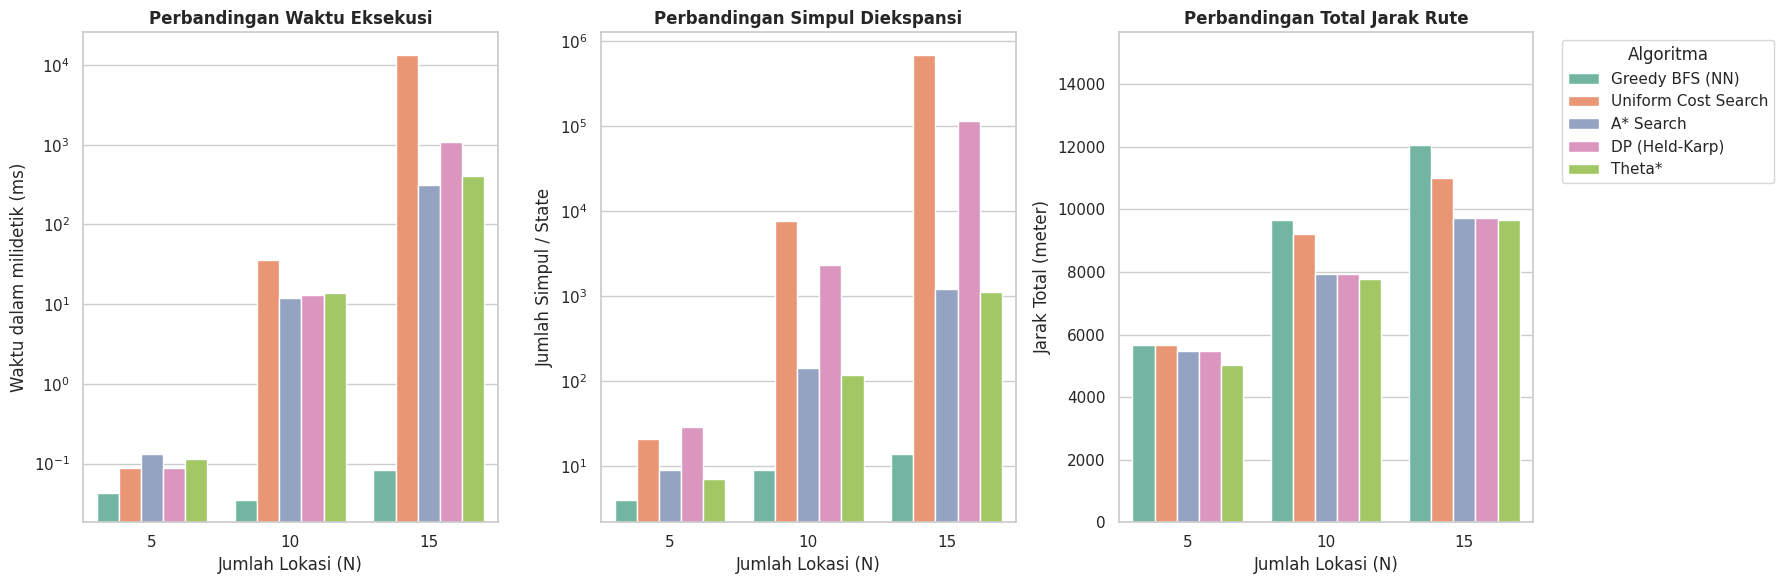

In [ ]:
# 10. Visualisasi Graf Sederhana
plt.figure(figsize=(10,6))
for name, (lat, lon) in LOKASI.items():
    plt.scatter(lon, lat, c='red')
    plt.text(lon, lat, name, fontsize=8)
plt.title("Visualisasi Sebaran 15 Lokasi Belanja Singapura")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.grid(True)
plt.show()

## Kesimpulan Eksperimen
Berdasarkan hasil pengujian eksperimental terhadap permasalahan pencarian rute wisata (TSP) menggunakan lima variasi algoritma pada berbagai skala ruang pencarian (N = 5, 10, 15), dapat ditarik beberapa kesimpulan utama:

1. **Trade-Off Optimalitas dan Kecepatan (Kinerja Greedy):**
   Algoritma *Greedy Best-First Search (Nearest Neighbor)* terbukti memiliki waktu eksekusi paling cepat dan eksplorasi simpul paling sedikit (tumbuh secara linier). Namun, efisiensi ini mengorbankan kualitas solusi; jarak total yang dihasilkan selalu menjadi yang terpanjang (paling sub-optimal) saat ruang pencarian membesar (N=15).

2. **Degradasi Kinerja Heuristik Lemah pada A*:**
   Visualisasi membuktikan bahwa algoritma A* dengan heuristik Euclidean sederhana (jarak ke titik berikutnya) gagal memangkas ruang pencarian secara signifikan. Jumlah simpul yang dievaluasi oleh A* hampir identik dengan pencarian buta (*Uniform Cost Search*), hingga menyentuh ratusan ribu simpul pada N=15. Akibatnya, waktu komputasi A* menjadi yang paling lambat karena adanya *overhead* (beban tambahan) perhitungan heuristik di setiap simpul yang diekspansi.

3. **Keunggulan Dynamic Programming (Held-Karp):**
   Untuk skala kecil hingga menengah (N <= 15), *Dynamic Programming* terbukti menjadi pendekatan yang sangat superior untuk mencari solusi eksak. DP secara konsisten menghasilkan jarak paling optimal (sejajar dengan A*), namun dengan jumlah *state* yang dievaluasi dan waktu eksekusi yang jauh lebih efisien berkat teknik *overlapping subproblems* (penyimpanan memori status).

4. **Efisiensi Heuristik MST pada Theta*:**
   Penggunaan *Minimum Spanning Tree* (MST) sebagai fungsi heuristik pada algoritma Theta* menunjukkan efektivitas pemangkasan (*pruning*) yang luar biasa. Theta* mampu menekan jumlah simpul yang dievaluasi secara drastis dibandingkan A*, menghasilkan waktu komputasi yang sangat cepat, sekaligus menjaga total jarak rute berada di tingkat yang optimal atau sangat mendekati optimal (*near-optimal*).

---

## Matriks Perbandingan Kualitatif

Tabel berikut merangkum karakteristik dan *trade-off* dari masing-masing algoritma berdasarkan grafik komparasi empiris:

| Kategori Evaluasi | Greedy BFS | Uniform Cost Search | A* Search (Heuristik Lemah) | DP (Held-Karp) | Theta* (Heuristik MST) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Optimalitas Jarak** | Sangat Rendah | Sedang / Terbatas | **Sangat Tinggi** (Eksak) | **Sangat Tinggi** (Eksak) | Tinggi (*Near-Optimal*) |
| **Kecepatan Eksekusi** | **Sangat Cepat** | Lambat | Paling Lambat | Cepat | Cepat |
| **Ruang Eksplorasi** | Sangat Minimal | Sangat Masif | Sangat Masif | Terukur (*Bitmask*) | Minimal (*Pruning* Kuat) |
| **Skalabilitas** | **Sangat Baik** | Buruk | Buruk | Terbatas (N <= 20) | Baik |
| **Rekomendasi Penggunaan**| Aplikasi respons cepat yang menoleransi rute panjang. | Baseline evaluasi pencarian tanpa panduan. | Pembelajaran dasar *Informed Search*. | Pencarian rute absolut optimal untuk lokasi terbatas. | Pencarian rute efisien dengan jarak yang kompetitif. |

---
